In [46]:
import pandas as pd
import json
import os
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import itertools
import re

In [30]:
def fasta_to_df(fasta_file):
    
    fasta_data = []
    
    with open(fasta_file) as f:
        header = ""
        sequence = ""
        for line in f:
            if line.startswith(">"):
                if header != "":
                    fasta_data.append({"header": header, "sequence": sequence})
                header = line.strip() 
                sequence = ""
            else:
                sequence += line.strip()
        fasta_data.append({"header": header, "sequence": sequence}) #last line
            
    return pd.DataFrame(fasta_data)

def fasta_writer(path, filename, df):
            
    try:  
        os.mkdir(path)

    except OSError as error:
        pass

    with open(f"{path}{filename}", "w") as f:
        for index, row in df.iterrows():
            f.write(f"{row['header']}\n")
            f.write(f"{row['sequence']}\n")


In [31]:
clades = ['eurasian_avian', 'na_avian']

In [32]:
clade_subtypes = {}

for clade in clades:
    
    meta_file = f"files/{clade}/metadata.csv"
    fasta_file = f"files/{clade}/h3nx_na.fasta"
    
    
    meta = pd.read_csv(meta_file)
    fasta = fasta_to_df(fasta_file)
    
    fasta["header"] = fasta["header"].str.lstrip(">")
    
    meta = meta[meta["strain"].isin(fasta["header"])].copy()
    
    subtype_counts = (
        meta.loc[meta["subtype"] != "H3", "subtype"]
        .value_counts()
    )
    
    props = (subtype_counts / subtype_counts.sum()).to_dict()

    clade_subtypes[clade] = props
    
    

In [33]:
clade_subtypes

{'eurasian_avian': {'H3N8': 0.615675165250236,
  'H3N2': 0.20018885741265344,
  'H3N6': 0.11898016997167139,
  'H3N1': 0.027384324834749764,
  'H3N3': 0.0226628895184136,
  'H3N7': 0.007554296506137866,
  'H3N4': 0.003777148253068933,
  'H3N5': 0.0028328611898017,
  'H3N9': 0.0009442870632672333},
 'na_avian': {'H3N8': 0.5644891122278057,
  'H3N2': 0.2068676716917923,
  'H3N6': 0.1323283082077052,
  'H3N1': 0.04355108877721943,
  'H3N5': 0.018425460636515914,
  'H3N7': 0.01256281407035176,
  'H3N3': 0.010887772194304857,
  'H3N9': 0.010050251256281407,
  'H3N4': 0.0008375209380234506}}

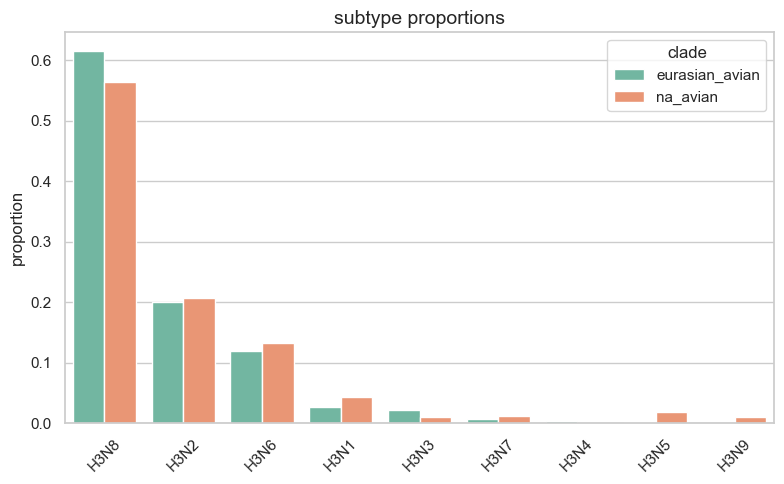

In [34]:
df = pd.DataFrame([
    {'clade': clade, 'subtype': subtype, 'proportion': prop}
    for clade, subdict in clade_subtypes.items()
    for subtype, prop in subdict.items()
])

sns.set(style="whitegrid", palette="Set2")

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df,
    x='subtype',
    y='proportion',
    hue='clade'
)

# ax.set_yscale('log')

ax.set_title("subtype proportions", fontsize=14)
ax.set_ylabel("proportion", fontsize=12)
ax.legend(title="clade")
ax.set_xlabel("")  
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
clade_prob_within = {
    clade: sum(p**2 for p in props.values())
    for clade, props in clade_subtypes.items()
}


In [36]:
clade_prob_within

{'eurasian_avian': 0.4346315274177626, 'na_avian': 0.38156724437373923}

In [37]:
clade_prob_between = {
    clade: 1 - within_prob
    for clade, within_prob in clade_prob_within.items()
}


In [38]:
clade_prob_between

{'eurasian_avian': 0.5653684725822374, 'na_avian': 0.6184327556262608}

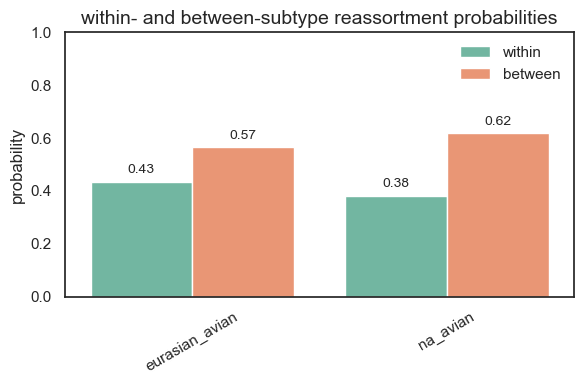

In [39]:
df = pd.DataFrame([
    {'clade': clade, 'type': 'within', 'prob': prob}
    for clade, prob in clade_prob_within.items()
] + [
    {'clade': clade, 'type': 'between', 'prob': prob}
    for clade, prob in clade_prob_between.items()
])

sns.set(style="white", palette="Set2")

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=df,
    x='clade',
    y='prob',
    hue='type'
)

for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width() / 2,
        y=height + 0.02, 
        s=f"{height:.2f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_ylim(0, 1)
ax.set_ylabel("probability", fontsize=12)
ax.set_title("within- and between-subtype reassortment probabilities", fontsize=14)
ax.set_xlabel("")
ax.legend(frameon=False)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [40]:
def compute_divergence(seq1, seq2):
    
    s1 = np.frombuffer(seq1.encode("utf-8"), dtype='S1')
    s2 = np.frombuffer(seq2.encode("utf-8"), dtype='S1')

    valid = (
        (s1 != b'-') & (s2 != b'-') &
        (s1 != b'N') & (s2 != b'N') &
        (s1 != b'n') & (s2 != b'n')
    )

    n_valid = valid.sum()
        
    if n_valid == 0:
        return np.nan
    
    mismatches = np.sum((s1 != s2) & valid) # not dividing by sites to keep consistent with treesort div values
    return mismatches 

def count_valid_sites(seq):
    s = np.frombuffer(seq.encode("utf-8"), dtype='S1')
    valid = (s != b'-') & (s != b'N') & (s != b'n')
    return valid.sum()

In [41]:
 exclude_strains = [
        "A/American_black_duck/Newfoundland/734/2008|2008-09-19",
        "A/mallard/Ohio/184/1986|1986-11-06",
        "A/blue-winged_teal/Guatemala/CIP049H102-32/2011|2011-11-11",
        "A/green-winged_teal/Alaska/UGAI16-4602/2016|2016-09-15",
        "A/duck/Mongolia/210/2018|2018-09-02",
        "A/mallard/Alberta/203/2015|2015-08-11"
    ]

In [42]:
clade_dfs = {}

for clade in clades:
    
    df2 = fasta_to_df(f"files/{clade}/h3nx_na.fasta")
    meta = pd.read_csv(f"files/{clade}/metadata.csv")

    df2["strain"] = df2["header"].str.lstrip(">")
    df2 = df2.merge(meta, left_on="strain", right_on="strain", how="left")

    # mistyped strains, need to fix in the metadata as well 

    df2 = df2[~df2["strain"].isin(exclude_strains)]

    df2 = df2[df2["subtype"] != "H3"]

    # filtering out low quality sequences

    df2["seq_len"] = df2["sequence"].str.len()

    df2["n_valid_sites"] = df2["sequence"].apply(count_valid_sites)

    # maximum length per subtypes 

    max_len_per_subtype = df2.groupby("subtype")["seq_len"].max().to_dict()

    length_threshold = 0.8   # keep sequences ≥80% of max subtype length
    valid_threshold = 0.8    # keep sequences with ≥80% valid sites relative to their length

    df_filtered = df2[
        df2.apply(
            lambda row: (row.seq_len >= length_threshold * max_len_per_subtype[row.subtype]) and
                        (row.n_valid_sites / row.seq_len >= valid_threshold),
            axis=1
        )
    ]

    records = []
    for (i, row1), (j, row2) in itertools.combinations(df_filtered.iterrows(), 2):
        div = compute_divergence(row1.sequence, row2.sequence)
        records.append({
            "strain1": row1.strain,
            "strain2": row2.strain,
            "subtype1": row1.subtype,
            "subtype2": row2.subtype,
            "divergence": div,
            "comparison": "within" if row1.subtype == row2.subtype else "between"
        })
    
    clade_dfs[clade] = pd.DataFrame(records)


/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


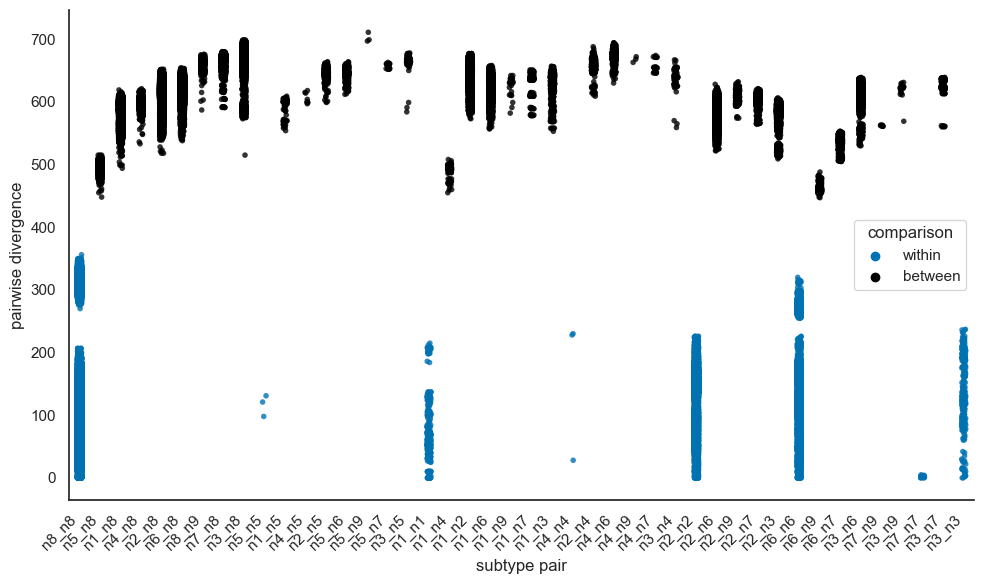

/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


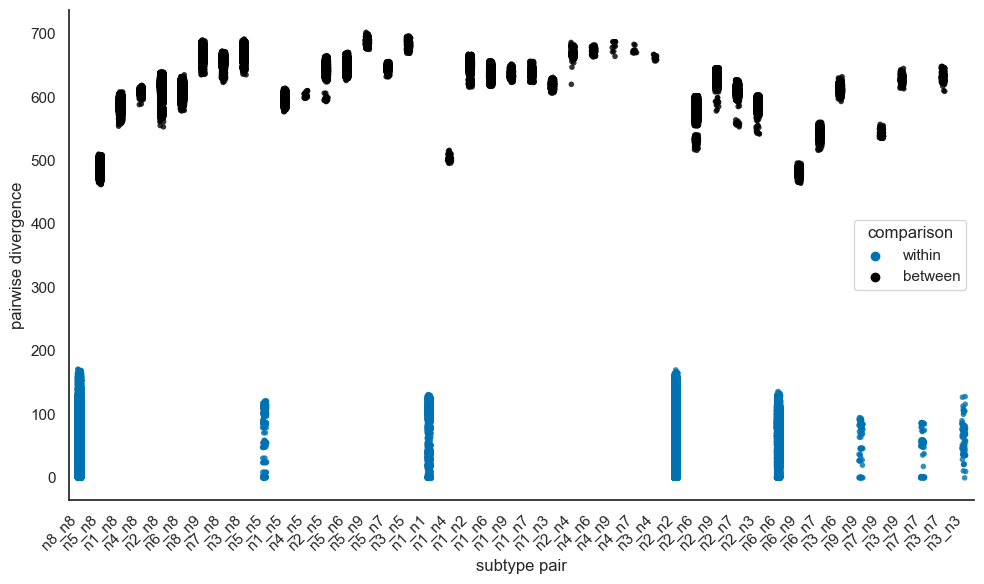

In [43]:
def make_pair(s1, s2):
    pair = "_".join(sorted([s1.replace("H3", "").lower(), s2.replace("H3", "").lower()]))
    return pair

for clade, div_df in clade_dfs.items():

    div_df["subtype_pair"] = div_df.apply(lambda x: make_pair(x.subtype1, x.subtype2), axis=1)
    div_df["comparison"] = div_df.apply(lambda x: "within" if x.subtype1 == x.subtype2 else "between", axis=1)


    plt.figure(figsize=(10, 6))
    sns.stripplot(
        data=div_df,
        x="subtype_pair",
        y="divergence",
        hue="comparison",
        dodge=False,
        palette={"within": "#0072B2", "between": "black"},
        alpha=0.8,
        size=4
    )

    plt.xticks(rotation=45, ha="right")
    plt.xlabel("subtype pair")
    plt.ylabel("pairwise divergence")
    sns.despine()
    plt.tight_layout()
    
    try:  
        os.mkdir(f"plots/{clade}/")

    except OSError as error:
        pass
    
    plt.savefig(f"plots/{clade}/pairwise_div_analysis.pdf", dpi=300, bbox_inches="tight")
    plt.show()


Lower cutoff (within) for eurasian_avian: 356
Upper cutoff (between) for eurasian_avian: 447




/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_

Lower cutoff (within) for na_avian: 171
Upper cutoff (between) for na_avian: 462




/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_

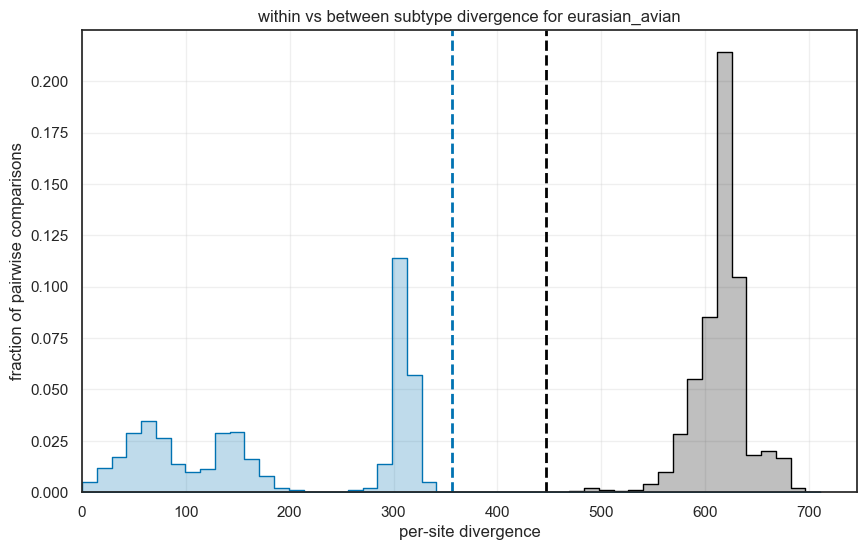

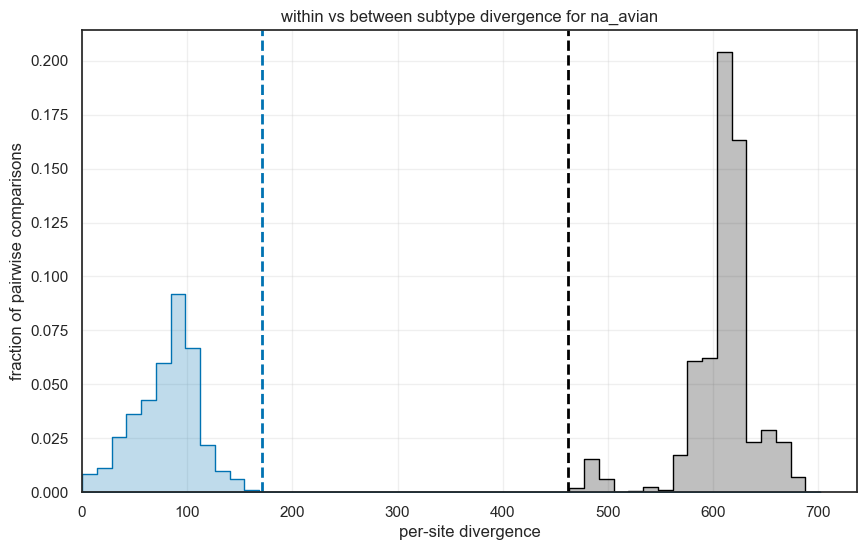

In [44]:
for clade, div_df in clade_dfs.items():

    within_cutoff = div_df.loc[div_df["comparison"]=="within", "divergence"].max()
    between_cutoff = div_df.loc[div_df["comparison"]=="between", "divergence"].min()

    print(f"Lower cutoff (within) for {clade}: {within_cutoff}")
    print(f"Upper cutoff (between) for {clade}: {between_cutoff}")
    print('\n')
    
    plt.figure(figsize=(10, 6))

    palette = {"within": "#0072B2", "between": "black"}

    sns.histplot(
        data=div_df,
        x="divergence",
        hue="comparison",
        bins=50,
        stat="probability", # scales y-axis to fraction of total comparisons
        element="step",
        palette=palette 
    )

    plt.xlim(left=0)

    # vertical dashed lines for global cutoffs
    plt.axvline(within_cutoff, color='#0072B2', linestyle='--', linewidth=2, label='within-subtype cutoff')
    plt.axvline(between_cutoff, color='black', linestyle='--', linewidth=2, label='between-subtype cutoff')

    plt.xlabel("per-site divergence")
    plt.ylabel("fraction of pairwise comparisons")
    plt.title(f"within vs between subtype divergence for {clade}")
    plt.legend().set_visible(False)
    plt.grid(alpha=0.3)
    plt.savefig(f"plots/{clade}/pairwise_div_histo.pdf", dpi=300, bbox_inches="tight")

In [47]:
divs = {}

for clade in clades:

    NA_div = {}

    with open(f'files/{clade}/summary.json', "r") as file:
        data = json.load(file)

    for name, node_data in data["nodes"].items():

        # only consider nodes that list NA as a high support reassorting segment

        if "NA" in node_data.get("segments", ""):

            divergence_str = node_data.get("divergence", "")

            # only extract the divergence value for NA

            match = re.search(r"NA\((\d+)\)", divergence_str)

            NA_div[name] = int(match.group(1))
            
    divs[clade] = NA_div

eurasian_avian:
18 values <= within cutoff, 
95 values > within cutoff


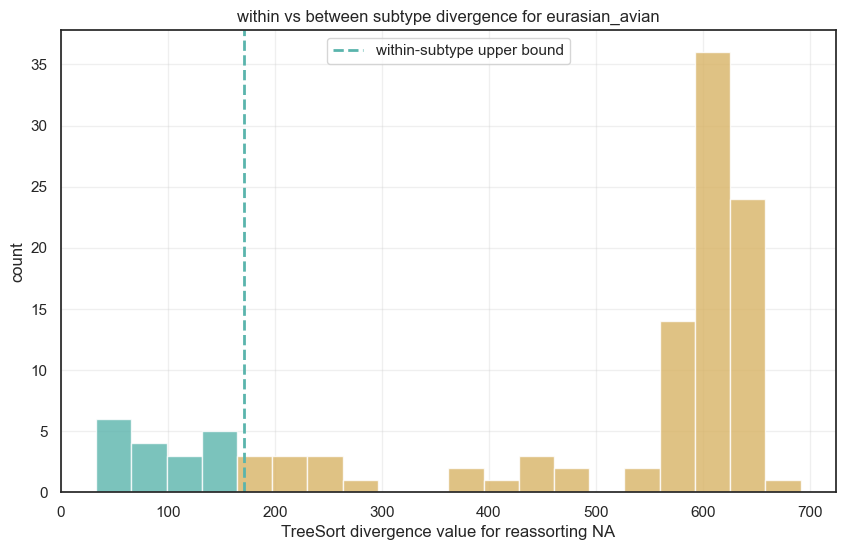

na_avian:
35 values <= within cutoff, 
138 values > within cutoff


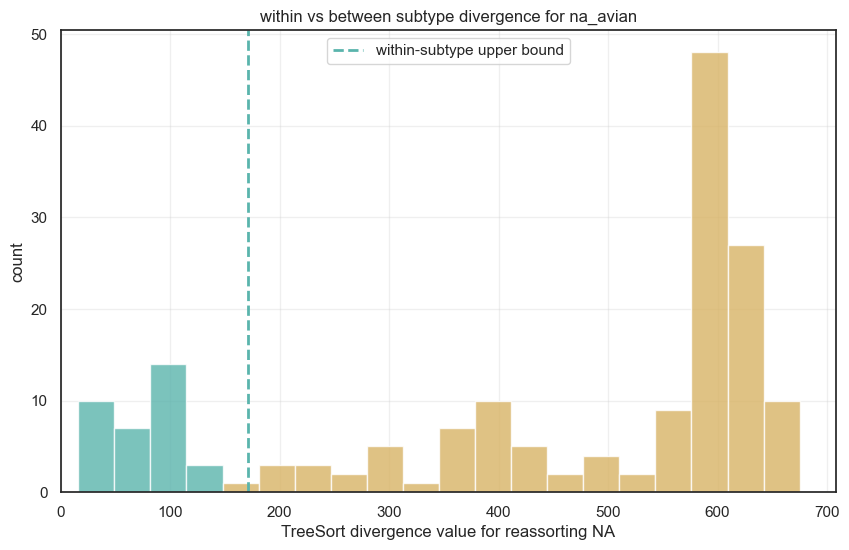

In [48]:
div_counts = {}

for clade, div in divs.items():
    
    df = pd.DataFrame(list(div.items()), columns=["name", "divergence"])
    
    below_cutoff = (df['divergence'] <= within_cutoff).sum()
    above_cutoff = (df['divergence'] > within_cutoff).sum()
    print(f"{clade}:\n{below_cutoff} values <= within cutoff, \n{above_cutoff} values > within cutoff")
    
    div_counts[clade] = {"below_within_cutoff": int(below_cutoff),
                         "above_within_cutoff": int(above_cutoff)}
    
    plt.figure(figsize=(10, 6))

    bins = 20
    n, bins_edges, patches = plt.hist(
        df['divergence'],
        bins=bins,
        alpha=0.8
    )

    for patch, bin_left, bin_right in zip(patches, bins_edges[:-1], bins_edges[1:]):
        if bin_right > within_cutoff:
            patch.set_facecolor('#d8b365')
        else:
            patch.set_facecolor('#5ab4ac')

    plt.axvline(within_cutoff, color='#5ab4ac', linestyle='--', linewidth=2, label='within-subtype upper bound')

    plt.xlim(left=0)
    plt.xlabel("TreeSort divergence value for reassorting NA")
    plt.ylabel("count")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.title(f"within vs between subtype divergence for {clade}")
    plt.savefig(f"plots/{clade}/treesort_div_bound.pdf", dpi=300, bbox_inches="tight")
    plt.show()


In [49]:
div_counts

{'eurasian_avian': {'below_within_cutoff': 18, 'above_within_cutoff': 95},
 'na_avian': {'below_within_cutoff': 35, 'above_within_cutoff': 138}}

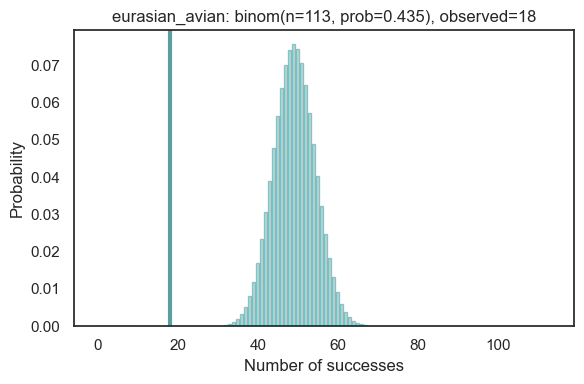

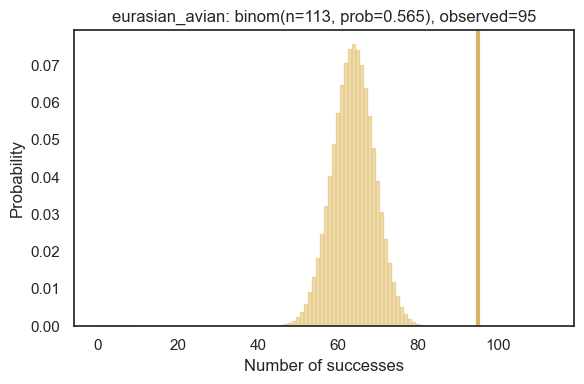

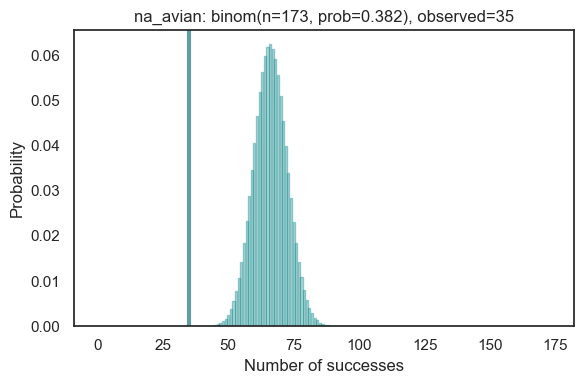

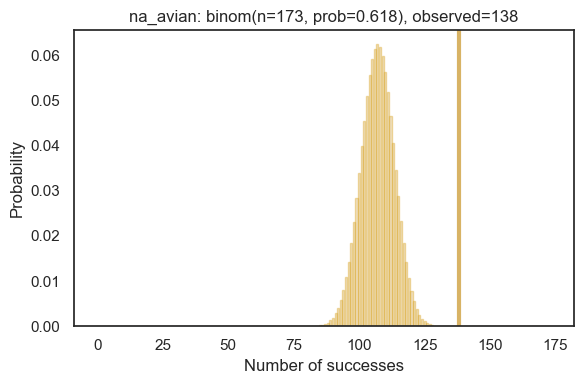

In [50]:
from scipy.stats import binom

for clade, vals in div_counts.items():
    
    within_vals = vals['below_within_cutoff']
    between_vals = vals['above_within_cutoff']

    # within
    n1 = within_vals + between_vals
    successes1 = within_vals
    p1 = clade_prob_within[clade]
    k1 = np.arange(0, n1 + 1)
    pmf1 = binom.pmf(k1, n1, p1)

    # within
    p_value_within = binom.cdf(successes1 - 1, n1, p1) # left-tailed, probability of ≥ observed

    plt.figure(figsize=(6,4))
    plt.bar(k1, pmf1, alpha=0.4, color='cadetblue',edgecolor="darkcyan")
    plt.axvline(successes1, linewidth=3, color='cadetblue')
    plt.xlabel("Number of successes")
    plt.ylabel("Probability")
    plt.title(f"{clade}: binom(n={n1}, prob={p1:.3f}), observed={successes1}")
    plt.tight_layout()
    plt.savefig(f"plots/{clade}/binomial_within.pdf", dpi=300, bbox_inches="tight")
    plt.show()

    # between
    n2 = within_vals + between_vals
    successes2 = between_vals
    p2 = clade_prob_between[clade]
    k2 = np.arange(0, n2 + 1)
    pmf2 = binom.pmf(k2, n2, p2)

    # between
    p_value_between = 1- binom.cdf(successes2 - 1, n2, p2) # right-tailed, Probability of ≤ observed

    plt.figure(figsize=(6,4))
    plt.bar(k2, pmf2, alpha=0.4, color='#d8b365', edgecolor="goldenrod")
    plt.axvline(successes2, linewidth=3, color='#d8b365')
    plt.xlabel("Number of successes")
    plt.ylabel("Probability")
    plt.title(f"{clade}: binom(n={n2}, prob={p2:.3f}), observed={successes2}")
    plt.savefig(f"plots/{clade}/binomial_between.pdf", dpi=300, bbox_inches="tight")
    plt.tight_layout()
    plt.show()